In [1]:
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.api as sm
from scipy import stats
import seaborn as sns

In [2]:
import os

current_dir = os.getcwd()

def load_data(file_name, drive_id, **kwargs):
    project_path = os.path.join(current_dir, 'data', file_name)
    local_pc_path = os.path.join(r'C:\Users\user\Desktop\Olist Dataset', file_name)
    url = f'https://drive.google.com/uc?export=download&id={drive_id}'
    
    if os.path.exists(project_path):
        return pd.read_csv(project_path, **kwargs)
    elif os.path.exists(local_pc_path):
        return pd.read_csv(local_pc_path, **kwargs)
    else:
        return pd.read_csv(url, **kwargs)

In [3]:
df = load_data('items_detailed.csv', '1vlOIljX6RENfcCku54dJBw1jal0hBNBi', encoding='utf-8', sep=',', parse_dates=['shipping_limit_date', 'order_purchase_timestamp'],
na_values = ['null', 'unknown', 'unavailable', 'error', 'NaN', 'NULL', 'UNKNOWN', 'ERROR'])

df

,seller_id,product_id,customer_id,order_id,order_item_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_status,customer_unique_id,customer_city,customer_state,product_name_length,product_description_length,product_photos_qnty,product_weight_g,seller_city,seller_state,product_category
0,48436dade18ac8b2bce089ec2a041202,4244733e06e7ecb4970a6e2683c13e61,3ce436f183e68e07877b285a838db11a,00010242fe8c5a6d1ba2dd792cb16214,1,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02,delivered,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,58.0,598.0,4.0,650.0,volta redonda,SP,cool_stuff
1,dd7ddc04e1b6c2c614352b383efe2d36,e5f2d52b802189ee658865ca93d83a8f,f6dd3ec061db4e3987629fe6b26e5cce,00018f77f2f0320c557190d7a144bdd3,1,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06,delivered,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,56.0,239.0,2.0,30000.0,sao paulo,SP,pet_shop
2,5b51032eddd242adc84c38acab88f23d,c777355d18b72b67abbeef9df44fd0fd,6489ae5e4333f3693df5ad4372dab6d3,000229ec398224ef6ca0657da4fc703e,1,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31,delivered,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,59.0,695.0,2.0,3050.0,borda da mata,MG,furniture_decor
3,9d7a1d34a5052409006425275ba1c2b4,7634da152a4610f1595efa32f14722fc,d4eb9395c8c0431ee92fce09860c5a06,00024acbcdf0a6daa1e931b038114c75,1,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35,delivered,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,42.0,480.0,1.0,200.0,franca,SP,perfumery
4,df560393f3a51e74553ab94004ba5c87,ac6c3623068f30de03045865e4e10089,58dbd0b2d70206bf40e62cd34e84d795,00042b26cf59d7ce69dfabb4e55b4fd9,1,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51,delivered,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,59.0,409.0,1.0,3750.0,loanda,PR,garden_tools
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,de23c3b98a88888289c6f5cc1209054a,7c1043bb5837db0c6bc1953419a18628,bca26aa1960632e9fcb269e5eb8faabd,ffc16cecff8dc037f60458f28d1c1ba5,2,2017-11-27 19:34:24,169.90,10.04,2017-11-21 19:25:15,delivered,77dcaacd61039f6aea366585acea9a20,campinas,SP,59.0,495.0,7.0,800.0,sao paulo,SP,stationery
112646,7d76b645482be4a332374e8223836592,c72d57da8ba2412527531d97106eb8ef,6f87e0dbbc2f842ebfe72a589cef6e9e,ffc184f2119c6fd4140dcfb518bf4734,1,2017-10-26 19:07:18,19.90,7.78,2017-10-22 18:50:04,delivered,666181047fa23359ca19d03abc679e18,itaquaquecetuba,SP,53.0,1311.0,2.0,50.0,sao paulo,SP,telephony
112647,95e03ca3d4146e4011985981aeb959b9,3cce0d166c3fb2507956c630c1d0f87c,d91334c0843c16865902f1eb2356811e,ffc1be2cfc663c95a4663eae09796e19,1,2017-12-06 00:22:09,79.90,16.32,2017-11-24 21:23:08,delivered,18cf733f47d311419adac897bfa46b70,sao sebastiao,SP,58.0,415.0,6.0,900.0,rio de janeiro,RJ,home_construction
112648,36a968b544695394e4e9d7572688598f,3f1a741cf5591384428c1cbb0ef07ec0,ada0af90cd5f4e7c13f84fb47e0a5628,ffc1fd8337b12fe96a4c39a0c2991296,1,2017-05-18 17:05:10,14.90,10.96,2017-05-03 16:51:47,delivered,65440681171bf517a0da7198eeb814f5,osasco,SP,60.0,400.0,1.0,150.0,santos,SP,health_beauty


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   seller_id                   112650 non-null  object        
 1   product_id                  112650 non-null  object        
 2   customer_id                 112650 non-null  object        
 3   order_id                    112650 non-null  object        
 4   order_item_id               112650 non-null  int64         
 5   shipping_limit_date         112650 non-null  datetime64[ns]
 6   price                       112650 non-null  float64       
 7   freight_value               112650 non-null  float64       
 8   order_purchase_timestamp    112650 non-null  datetime64[ns]
 9   order_status                112643 non-null  object        
 10  customer_unique_id          112650 non-null  object        
 11  customer_city               112650 non-

In [5]:
df.describe()

,order_item_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,product_name_length,product_description_length,product_photos_qnty,product_weight_g
count,112650.000000,112650,112650.000000,112650.000000,112650,111047.000000,111047.000000,111047.000000,112632.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320,2018-01-01 00:09:48.464376576,48.775978,787.867029,2.209713,2093.672047
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,2016-09-04 21:15:19,5.000000,4.000000,1.000000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000,2017-09-13 19:17:04,42.000000,348.000000,1.000000,300.000000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000,2018-01-19 23:02:16,52.000000,603.000000,1.000000,700.000000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000,2018-05-04 17:30:36.750000128,57.000000,987.000000,3.000000,1800.000000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,2018-09-03 09:06:57,76.000000,3992.000000,20.000000,40425.000000
std,0.705124,NaN,183.633928,15.806405,NaN,10.025581,652.135608,1.721438,3751.596884


In [6]:
df.isnull().sum()

seller_id                        0
product_id                       0
customer_id                      0
order_id                         0
order_item_id                    0
shipping_limit_date              0
price                            0
freight_value                    0
order_purchase_timestamp         0
order_status                     7
customer_unique_id               0
customer_city                    0
customer_state                   0
product_name_length           1603
product_description_length    1603
product_photos_qnty           1603
product_weight_g                18
seller_city                      0
seller_state                     0
product_category              1627
dtype: int64

In [7]:
df['is_within_city'] = (df['customer_city'] == df['seller_city']).astype(int)
df['is_within_state'] = (df['customer_state'] == df['seller_state']).astype(int)

In [8]:
df_orders = load_data('orders_detailed.csv', '1dLU6T8VOwqfDd6dvjQVu7icaY3c_bVMP', encoding='utf-8', sep=',', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
na_values = ['null', 'unknown', 'unavailable', 'error', 'NaN', 'NULL', 'UNKNOWN', 'ERROR'])

df_orders['delivery_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_approved_at'])
df_orders['delivery_delay'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date'])
df_orders['delivery_delay'] = df_orders['delivery_delay'].clip(lower=pd.Timedelta(0))

In [9]:
# MERGE ITEMS AND ORDERS TABLES

df_merged = df.merge(df_orders, on='order_id', how='left', validate='many_to_one')
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   seller_id                      112650 non-null  object         
 1   product_id                     112650 non-null  object         
 2   customer_id_x                  112650 non-null  object         
 3   order_id                       112650 non-null  object         
 4   order_item_id                  112650 non-null  int64          
 5   shipping_limit_date            112650 non-null  datetime64[ns] 
 6   price                          112650 non-null  float64        
 7   freight_value                  112650 non-null  float64        
 8   order_purchase_timestamp_x     112650 non-null  datetime64[ns] 
 9   order_status_x                 112643 non-null  object         
 10  customer_unique_id_x           112650 non-null  object  

In [10]:
(df_merged['customer_id_x'] == df_merged['customer_id_y']).all()
(df_merged['order_purchase_timestamp_x'] == df_merged['order_purchase_timestamp_y']).all()
(df_merged['customer_unique_id_x'] == df_merged['customer_unique_id_y']).all()
(df_merged['customer_city_x'] == df_merged['customer_city_y']).all()
(df_merged['customer_state_x'] == df_merged['customer_state_y']).all()
df_merged['order_status_x'].equals(df_merged['order_status_y'])

True

In [11]:
df_merged = df_merged.drop(columns=['customer_id_y', 'order_purchase_timestamp_y', 'customer_unique_id_y', 'customer_city_y', 'customer_state_y', 'order_status_y'])

new_names = {
    'customer_id_x': 'customer_id',
    'order_purchase_timestamp_x': 'order_purchase_timestamp',
    'customer_unique_id_x': 'customer_unique_id',
    'customer_city_x': 'customer_city',
    'customer_state_x': 'customer_state'
}

df_merged = df_merged.rename(columns=new_names)

In [12]:
# XYZ ANALYSIS

df_cut = df[(df['order_purchase_timestamp'] >= '2018-01-01') & (df['order_purchase_timestamp'] < '2018-08-31')].copy()
df_cut['month'] = df_cut['order_purchase_timestamp'].dt.to_period('M')

grouped = df_cut.groupby(['product_category', 'seller_id', 'month'])['price'].sum()

all_months = pd.period_range(start='2018-01', end='2018-08', freq='M')

new_index = pd.MultiIndex.from_product(
    [grouped.index.get_level_values(0).unique(), 
     grouped.index.get_level_values(1).unique(), 
     all_months],
    names=['product_category', 'seller_id', 'month']
)

sellers_categ = (grouped
                 .reindex(new_index, fill_value=0)
                 .reset_index())

real_presence = sellers_categ.groupby(['product_category', 'seller_id'])['price'].transform('sum') > 0
sellers_categ = sellers_categ[real_presence]



xyz_analysis = sellers_categ.groupby(['product_category', 'seller_id'])['price'].agg(
    mean_sales='mean',
    std_sales='std'
).reset_index()

xyz_analysis['cv'] = xyz_analysis['std_sales'] / xyz_analysis['mean_sales']

def xyz_classify(cv):
    if cv <= 0.1:
        return 'X'
    if cv <= 0.25:
        return 'Y'
    return 'Z'

xyz_analysis['xyz_class'] = xyz_analysis['cv'].apply(xyz_classify)

xyz_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4741 entries, 0 to 4740
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_category  4741 non-null   object 
 1   seller_id         4741 non-null   object 
 2   mean_sales        4741 non-null   float64
 3   std_sales         4741 non-null   float64
 4   cv                4741 non-null   float64
 5   xyz_class         4741 non-null   object 
dtypes: float64(3), object(3)
memory usage: 222.4+ KB


In [13]:
sellers_filt = xyz_analysis.dropna(subset=['cv']).copy()
sellers_filt

,product_category,seller_id,mean_sales,std_sales,cv,xyz_class
0,agro_industry_and_commerce,06579cb253ecd5a3a12a9e6eb6bf8f47,12.11250,34.259324,2.828427,Z
1,agro_industry_and_commerce,0ed6ce5d87fd9c69eaacaeb778d67235,63.08750,99.055373,1.570127,Z
2,agro_industry_and_commerce,1996942dc085d7773ba77a529b163cd0,69.99875,197.986363,2.828427,Z
3,agro_industry_and_commerce,2528744c5ef5d955adc318720a94d2e7,205.87500,284.134494,1.380131,Z
4,agro_industry_and_commerce,269cff2d3c8d205c11f37a52402ea93b,90.21125,136.566181,1.513849,Z
...,...,...,...,...,...,...
4736,watches_gifts,f9eda05b67bef472deaddbba84aca289,23.12500,65.407377,2.828427,Z
4737,watches_gifts,f9eedec3129e8cc6b6429c42d0808c5b,98.72500,279.236468,2.828427,Z
4738,watches_gifts,fa1c13f2614d7b5c4749cbc52fecda94,11755.46625,2647.363739,0.225203,Y
4739,watches_gifts,fcba71d4d5db057f43249145e4eb1e27,19.98750,56.533187,2.828427,Z


In [14]:
sellers_filt.duplicated(['product_category', 'seller_id']).sum()

np.int64(0)

In [15]:
temp = sellers_filt.groupby(['product_category', 'seller_id'])['cv'].mean().reset_index()

sellers_agg = temp.groupby('product_category').agg(
    avg_cv=('cv', 'mean'),
    median_cv=('cv', 'median'),
    pct_non_stable_sellers=('cv', lambda x: (x > 0.5).mean() * 100),
    pct_very_nonst_sellers=('cv', lambda x: (x > 1).mean() * 100)
)

sellers_agg

# UNCOMMENT THE FOLLOWING LINES TO VIEW THE FULL TABLE
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    display(sellers_agg)

,avg_cv,median_cv,pct_non_stable_sellers,pct_very_nonst_sellers
product_category,,,,
agro_industry_and_commerce,2.419779,2.828427,100.000000,96.969697
air_conditioning,2.264822,2.828427,100.000000,88.571429
art,2.237543,2.828427,95.000000,95.000000
arts_and_craftmanship,2.591554,2.828427,100.000000,100.000000
audio,2.238650,2.828427,95.238095,90.476190
...,...,...,...,...
stationery,2.059306,2.118570,99.300699,86.013986
tablets_printing_image,2.290136,2.290136,100.000000,100.000000
telephony,1.942443,1.891082,96.330275,84.403670


<Axes: xlabel='seller_id', ylabel='orders_count'>

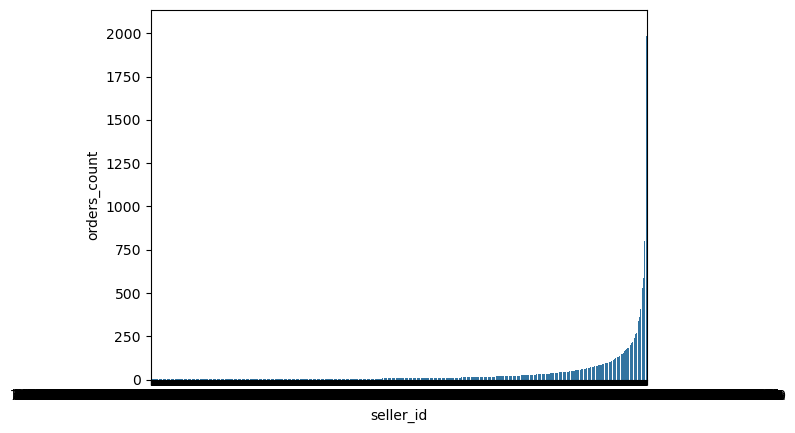

In [16]:
# ORDERS BY SELLERS

df_sellers = df.groupby('seller_id').size().reset_index(name='orders_count')
df_sellers = df_sellers.sort_values(by='orders_count')

sns.barplot(x='seller_id', y='orders_count', data=df_sellers)

<Axes: xlabel='seller_id', ylabel='orders_count'>

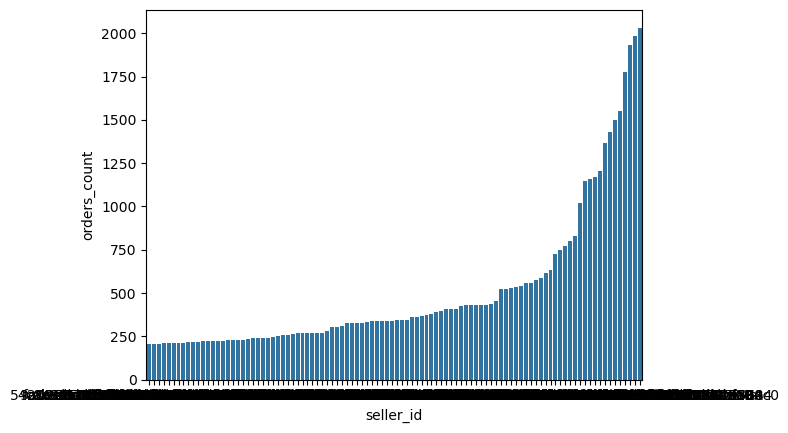

In [17]:
sns.barplot(x='seller_id', y='orders_count', data=df_sellers.tail(100))

In [18]:
# SELLERS' REVENUE SHARE WITHIN CATEGORIES

df_seller_stats = df.groupby(['product_category', 'seller_id'])['price'].sum().reset_index()

df_cats = df_seller_stats.groupby('product_category').agg(
    sellers_count = ('seller_id', 'nunique'),
    total_revenue = ('price', 'sum'),
    top5_sellers_revenue = ('price', lambda x: x.nlargest(5).sum())
).reset_index()

df_cats['top5_revenue_share'] = df_cats['top5_sellers_revenue'] / df_cats['total_revenue'] * 100

df_cats

# UNCOMMENT THE FOLLOWING LINES TO VIEW THE FULL TABLE
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    display(df_cats)

,product_category,sellers_count,total_revenue,top5_sellers_revenue,top5_revenue_share
0,agro_industry_and_commerce,34,72530.47,58594.73,80.786365
1,air_conditioning,52,55024.96,26921.33,48.925669
2,art,36,24202.64,19392.42,80.125226
3,arts_and_craftmanship,13,1814.01,1544.83,85.161052
4,audio,36,50688.50,39694.59,78.310840
...,...,...,...,...,...
66,stationery,173,230943.23,123835.01,53.621407
67,tablets_printing_image,6,7528.41,7483.71,99.406249
68,telephony,149,323667.53,130689.41,40.377671
69,toys,252,483946.60,143551.50,29.662674


In [19]:
df_cats['top5_revenue_share'].mean(), df_cats['total_revenue'].median()

(np.float64(66.95046437660945), 46856.88)

In [20]:
df_cats[df_cats['total_revenue'] > 46856]['top5_revenue_share'].mean()

np.float64(52.5820445277832)

In [21]:
df_cats[df_cats['total_revenue'] > 100000]['top5_revenue_share'].mean()

np.float64(45.04604212078773)

In [22]:
# ORDERS COUNT BY SELLERS WITHIN CATEGORIES

df_orders_stats = df.groupby(['product_category', 'seller_id'])['order_id'].count().reset_index()

df_ord_cats = df_orders_stats.groupby('product_category').agg(
    sellers_count = ('seller_id', 'nunique'),
    orders_count = ('order_id', 'sum'),
    orders_top5_sellers = ('order_id', lambda x: x.nlargest(5).sum())
).reset_index()

df_ord_cats['top5_orders_share'] = df_ord_cats['orders_top5_sellers'] / df_ord_cats['orders_count'] * 100

df_ord_cats

# UNCOMMENT THE FOLLOWING LINES TO VIEW THE FULL TABLE
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    display(df_ord_cats)

,product_category,sellers_count,orders_count,orders_top5_sellers,top5_orders_share
0,agro_industry_and_commerce,34,212,136,64.150943
1,air_conditioning,52,297,119,40.067340
2,art,36,209,143,68.421053
3,arts_and_craftmanship,13,24,16,66.666667
4,audio,36,364,267,73.351648
...,...,...,...,...,...
66,stationery,173,2517,1231,48.907429
67,tablets_printing_image,6,83,82,98.795181
68,telephony,149,4545,2469,54.323432
69,toys,252,4117,1219,29.608939


In [23]:
df_ord_cats['top5_orders_share'].mean()

np.float64(64.26106963748956)

In [24]:
# PENETRATION BY STATES

states = {
    'state_abb': [
        'SP', 'MG', 'RJ', 'ES', 'BA', 'PE', 'CE', 'MA', 'PB', 'RN', 
        'AL', 'PI', 'SE', 'PR', 'RS', 'SC', 'PA', 'AM', 'RO', 'TO', 
        'AC', 'AP', 'RR', 'GO', 'MT', 'DF', 'MS'
    ],
    'state_name': [
        'São Paulo', 'Minas Gerais', 'Rio de Janeiro', 'Espírito Santo', 'Bahia', 
        'Pernambuco', 'Ceará', 'Maranhão', 'Paraíba', 'Rio Grande do Norte', 
        'Alagoas', 'Piauí', 'Sergipe', 'Paraná', 'Rio Grande do Sul', 
        'Santa Catarina', 'Pará', 'Amazonas', 'Rondônia', 'Tocantins', 
        'Acre', 'Amapá', 'Roraima', 'Goiás', 'Mato Grosso', 'Distrito Federal', 
        'Mato Grosso do Sul'
    ],
    'population': [
        45538936, 21040662, 17159960, 3973697, 14812617, 
        9496294, 9075649, 7035055, 3996496, 3479010, 
        3322820, 3264531, 2278308, 11348937, 11329605, 
        7075494, 8513497, 4080611, 1757589, 1555229, 
        869265, 829494, 576568, 6921161, 3441238, 2974703, 2748023
    ],
    'mean_income': [
        1898, 1322, 1689, 1295, 841, 
        871, 855, 605, 898, 956, 
        714, 817, 906, 1607, 1705, 
        1660, 863, 791, 1113, 1045, 
        909, 857, 1204, 1323, 1386, 2460, 1439
    ],
    'median_income': [
        1200, 895, 1000, 900, 480, 
        515, 502, 400, 500, 540, 
        410, 490, 520, 1060, 1125, 
        1200, 510, 470, 800, 610, 
        530, 510, 711, 853, 954, 1500, 1000
    ]    
}

df_states_info = pd.DataFrame(states)

In [25]:
df_customers = df.groupby('customer_state').agg(
    customers_count=('customer_unique_id', 'nunique'),
    ave_freight=('freight_value', 'mean')
).reset_index()

df_sellers = df.groupby('seller_state').agg(
    sellers_count=('seller_id', 'nunique')
).reset_index()

df_states_agg = df_customers.merge(
    df_sellers,
    left_on='customer_state',
    right_on='seller_state',
    how='left'
).drop(columns='seller_state')

df_states_agg['sellers_count'] = (
    df_states_agg['sellers_count']
    .fillna(0)
    .astype(int)
)

df_states_agg

,customer_state,customers_count,ave_freight,sellers_count
0,AC,77,40.073370,1
1,AL,399,35.843671,0
2,AM,142,33.205394,1
3,AP,67,34.006098,0
4,BA,3257,26.363959,19
5,CE,1305,32.714202,13
6,DF,2062,21.041355,30
7,ES,1956,22.058777,23
8,GO,1942,22.766815,40
9,MA,719,38.257002,1


In [26]:
df_states = df_states_agg.merge(df_states_info, left_on='customer_state', right_on='state_abb', how='right', validate='one_to_one')
df_states = df_states.drop('state_abb', axis=1)
df_states = df_states.rename(columns={'customer_state': 'state_abb'})

# the penetration rate is relative and shows the percentage of the population involved multiplied by 1000
df_states['penetration_rate'] = df_states['customers_count'] / df_states['population'] * 100000

df_states

,state_abb,customers_count,ave_freight,sellers_count,state_name,population,mean_income,median_income,penetration_rate
0,SP,39981,15.147275,1849,São Paulo,45538936,1898,1200,87.795200
1,MG,11178,20.630167,244,Minas Gerais,21040662,1322,895,53.125705
2,RJ,12303,20.960924,171,Rio de Janeiro,17159960,1689,1000,71.695971
3,ES,1956,22.058777,23,Espírito Santo,3973697,1295,900,49.223683
4,BA,3257,26.363959,19,Bahia,14812617,841,480,21.988012
5,PE,1605,32.917863,9,Pernambuco,9496294,871,515,16.901330
6,CE,1305,32.714202,13,Ceará,9075649,855,502,14.379137
7,MA,719,38.257002,1,Maranhão,7035055,605,400,10.220247
8,PB,516,42.723804,6,Paraíba,3996496,898,500,12.911310
9,RN,471,35.652363,5,Rio Grande do Norte,3479010,956,540,13.538334


In [27]:
output_dir = 'output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

file_path = os.path.join(output_dir, 'states.csv')
df_states.to_csv(file_path, index=False)

In [28]:
df_states['penetration_rate'].mean(), df_states['penetration_rate'].median()

(np.float64(27.775323237358137), 16.901330139947223)

In [29]:
df_states[df_states['penetration_rate'] < 20][['state_name', 'population', 'penetration_rate']]

,state_name,population,penetration_rate
5,Pernambuco,9496294,16.901330
6,Ceará,9075649,14.379137
7,Maranhão,7035055,10.220247
8,Paraíba,3996496,12.911310
9,Rio Grande do Norte,3479010,13.538334
10,Alagoas,3322820,12.007873
11,Piauí,3264531,14.734123
12,Sergipe,2278308,14.835571
16,Pará,8513497,11.088275
17,Amazonas,4080611,3.479871


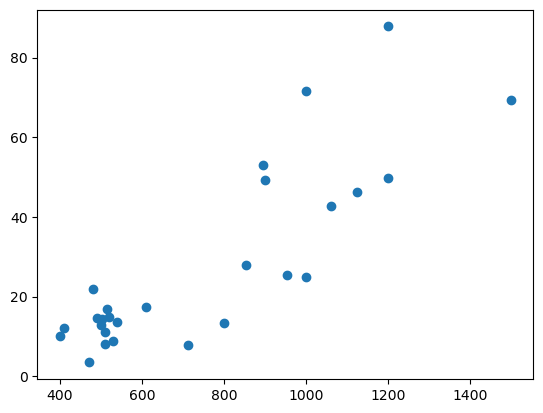

In [30]:
import matplotlib.pyplot as plt

plt.scatter(df_states['median_income'], df_states['penetration_rate'])

<Axes: xlabel='median_income', ylabel='penetration_rate'>

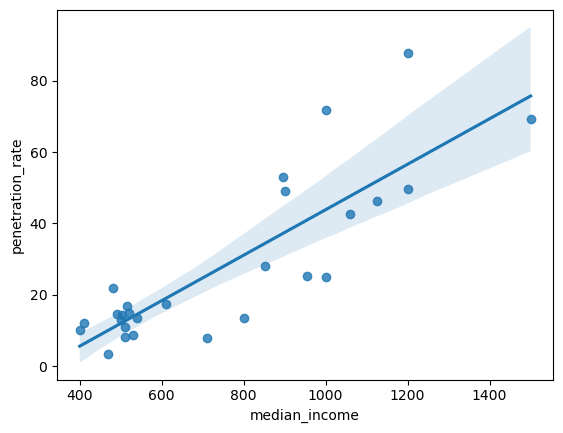

In [31]:
sns.regplot(x='median_income', y='penetration_rate', data=df_states)

In [32]:
# PENETRATION RATE AND MEDIAN INCOME

y = df_states['penetration_rate']
x = sm.add_constant(df_states['median_income'])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       penetration_rate   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.700
Method:                 Least Squares   F-statistic:                     48.82
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.53e-07
Time:                        17:48:57   Log-Likelihood:                -105.31
No. Observations:                  27   AIC:                             214.6
Df Residuals:                      25   BIC:                             217.2
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -19.8860      5.305     -3.748

In [33]:
# PENETRATION RATE AND FREIGHT VALUE

y = df_states['penetration_rate']
x = sm.add_constant(df_states['ave_freight'])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       penetration_rate   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     41.41
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           9.73e-07
Time:                        17:48:57   Log-Likelihood:                -104.22
No. Observations:                  27   AIC:                             212.4
Df Residuals:                      25   BIC:                             215.0
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          98.6485     12.447      7.926      

In [34]:
# PENETRATION RATE AND (MEDIAN INCOME, FREIGHT VALUE)

y = df_states['penetration_rate']
x = sm.add_constant(df_states[['median_income', 'ave_freight']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       penetration_rate   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     38.14
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.53e-08
Time:                        17:48:58   Log-Likelihood:                -99.444
No. Observations:                  27   AIC:                             204.9
Df Residuals:                      24   BIC:                             208.8
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            44.4291     13.763      3.228

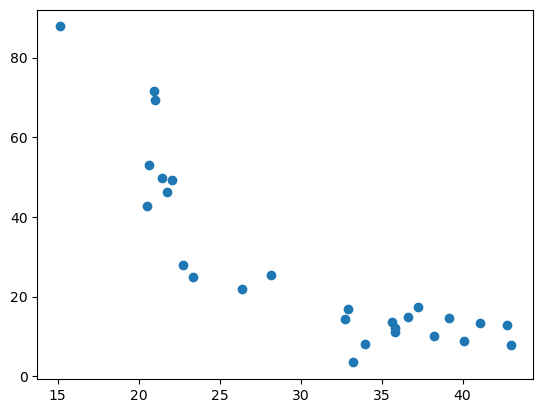

In [35]:
import matplotlib.pyplot as plt

plt.scatter(df_states['ave_freight'], df_states['penetration_rate'])

<Axes: xlabel='ave_freight', ylabel='penetration_rate'>

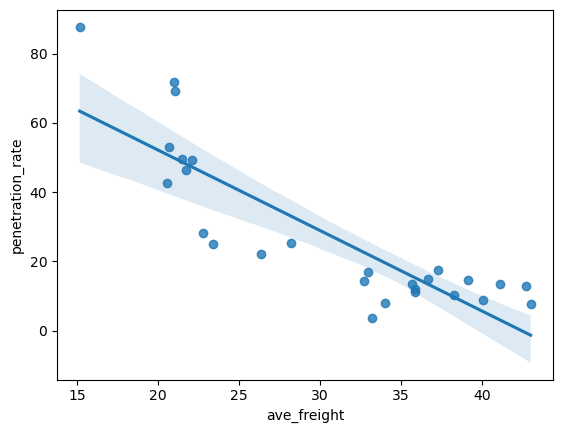

In [36]:
sns.regplot(x='ave_freight', y='penetration_rate', data=df_states)

In [37]:
# PENETRATION RATE AND (MEDIAN INCOME, FREIGHT VALUE) WITH INTERACTION TERM

df_states['freight_income'] = df_states['ave_freight'] * df_states['median_income']

y = df_states['penetration_rate']
x = sm.add_constant(df_states[['median_income', 'ave_freight', 'freight_income']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       penetration_rate   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     32.72
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.80e-08
Time:                        17:49:00   Log-Likelihood:                -95.145
No. Observations:                  27   AIC:                             198.3
Df Residuals:                      23   BIC:                             203.5
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -29.4463     32.106     -0.

In [38]:
# SALES WITHING AND BETWEEN CITIES AND STATES

df_local = (df.assign(
    is_within_city = df['customer_city'] == df['seller_city'],
    is_within_state = df['customer_state'] == df['seller_state']
)).groupby('product_category').agg(
    within_city = ('is_within_city', 'sum'),
    cities_total = ('customer_city', 'count'),
    within_state = ('is_within_state', 'sum'),
    states_total = ('customer_state', 'count'),
    orders_count = ('product_id', 'count')
).reset_index().copy()
df_local['within_city_%'] = df_local['within_city'] / df_local['cities_total'] * 100
df_local['within_state_%'] = df_local['within_state'] / df_local['states_total'] * 100

df_local.sort_values('within_city_%', ascending=False, inplace=True)
df_local.sort_values('orders_count', ascending=False, inplace=True)

df_local[['product_category', 'orders_count', 'within_city_%', 'within_state_%']]

# UNCOMMENT THE FOLLOWING LINES TO VIEW THE FULL TABLE
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    display(df_local[['product_category', 'orders_count', 'within_city_%', 'within_state_%']])

,product_category,orders_count,within_city_%,within_state_%
7,bed_bath_table,11115,2.519118,43.553756
43,health_beauty,9670,5.532575,37.001034
65,sports_leisure,8641,5.138294,34.394167
39,furniture_decor,8334,5.435565,36.093113
15,computers_accessories,7827,4.139517,27.111281
...,...,...,...,...
3,arts_and_craftmanship,24,0.000000,70.833333
11,cds_dvds_musicals,14,0.000000,42.857143
52,la_cuisine,14,0.000000,14.285714
29,fashion_childrens_clothes,8,25.000000,25.000000


In [39]:
# FREIGHT VALUE AND GEOLOCATION (CITY)

df_clean = df[['is_within_city', 'is_within_state', 'product_weight_g', 'freight_value', 'price']].dropna().copy()

y = df_clean['freight_value']
x = sm.add_constant(df_clean[['is_within_city', 'product_weight_g']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          freight_value   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     7749.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:49:00   Log-Likelihood:            -4.4331e+05
No. Observations:              112632   AIC:                         8.866e+05
Df Residuals:                  112629   BIC:                         8.867e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               15.0624      0.055  

In [40]:
# FREIGHT VALUE AND WEIGHT

y = df_clean['freight_value']
x = sm.add_constant(df_clean[['product_weight_g']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          freight_value   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     6010.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:49:01   Log-Likelihood:            -4.4448e+05
No. Observations:              112632   AIC:                         8.890e+05
Df Residuals:                  112630   BIC:                         8.890e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               14.6061      0.054  

In [41]:
# FREIGHT VALUE AND LOCATION ONLY. WITHOUGHT WEIGHT

y = df_clean['freight_value']
x = sm.add_constant(df_clean[['is_within_state']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          freight_value   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                 1.708e+04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:49:01   Log-Likelihood:            -4.6500e+05
No. Observations:              112632   AIC:                         9.300e+05
Df Residuals:                  112630   BIC:                         9.300e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              23.6949      0.066    3

In [42]:
# FREIGHT VALUE AND GEOLOCATION (STATE)

y = df_clean['freight_value']
x = sm.add_constant(df_clean[['is_within_state', 'product_weight_g']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          freight_value   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                 1.451e+04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:49:01   Log-Likelihood:            -4.3510e+05
No. Observations:              112632   AIC:                         8.702e+05
Df Residuals:                  112629   BIC:                         8.702e+05
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               18.3028      0.053  

In [43]:
df_clean['rel_freight'] = df_clean['freight_value'] / df_clean['price']

In [44]:
# FREIGHT/PRICE AND GEOLOCATION (STATE)

y = df_clean['rel_freight']
x = sm.add_constant(df_clean[['is_within_state', 'product_weight_g']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            rel_freight   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     2153.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:49:01   Log-Likelihood:                -39647.
No. Observations:              112632   AIC:                         7.930e+04
Df Residuals:                  112629   BIC:                         7.933e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3806      0.002  

In [45]:
df_merged_clean = df_merged[['is_within_city', 'is_within_state', 'delivery_days', 'delivery_delay', 'review_score', 'freight_value', 'price', 'order_estimated_delivery_date', 'order_approved_at']].dropna().copy()
df_merged_clean['delay_days'] = df_merged_clean['delivery_delay'].dt.total_seconds() / 86400

In [46]:
# DELAY AND GEOLOCATION (CITY)

y = df_merged_clean['delay_days']
x = sm.add_constant(df_merged_clean[['is_within_city']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             delay_days   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     152.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.53e-35
Time:                        17:49:01   Log-Likelihood:            -3.2091e+05
No. Observations:              109354   AIC:                         6.418e+05
Df Residuals:                  109352   BIC:                         6.418e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.7486      0.014     51.

In [47]:
# DELAY AND GEOLOCATION (STATE)

y = df_merged_clean['delay_days']
x = sm.add_constant(df_merged_clean[['is_within_state']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             delay_days   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     462.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          1.87e-102
Time:                        17:49:02   Log-Likelihood:            -3.2076e+05
No. Observations:              109354   AIC:                         6.415e+05
Df Residuals:                  109352   BIC:                         6.415e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.9232      0.020     

In [48]:
# REVIEW SCORE AND DELAY GIVEN THE GEOLOCATION (CITY)

df_merged_clean['delay_city'] = df_merged_clean['is_within_city'] * df_merged_clean['delay_days']
df_merged_clean['delay_state'] = df_merged_clean['is_within_state'] * df_merged_clean['delay_days']

y = df_merged_clean['review_score']
x = sm.add_constant(df_merged_clean[['is_within_city', 'delay_days', 'delay_city']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     146.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           1.96e-94
Time:                        17:49:02   Log-Likelihood:            -1.8416e+05
No. Observations:              109354   AIC:                         3.683e+05
Df Residuals:                  109350   BIC:                         3.684e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.1263      0.005    887.

In [49]:
# REVIEW SCORE & LOCATION

y = df_merged_clean['review_score']
x = sm.add_constant(df_merged_clean[['is_within_city']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     120.7
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.65e-28
Time:                        17:49:02   Log-Likelihood:            -1.8761e+05
No. Observations:              109354   AIC:                         3.752e+05
Df Residuals:                  109352   BIC:                         3.752e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.0722      0.004    970.

In [50]:
# REVIEW SCORE AND DELAY GIVEN THE GEOLOCATION (STATE)

y = df_merged_clean['review_score']
x = sm.add_constant(df_merged_clean[['is_within_state', 'delay_days', 'delay_state']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     260.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          2.04e-168
Time:                        17:49:02   Log-Likelihood:            -1.8407e+05
No. Observations:              109354   AIC:                         3.681e+05
Df Residuals:                  109350   BIC:                         3.682e+05
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.0837      0.006    6

In [51]:
df_merged_clean['delivery_days'] = (df_merged_clean['order_estimated_delivery_date'] - df_merged_clean['order_approved_at']).dt.total_seconds() / 86400
df_merged_clean['delay_ratio'] = df_merged_clean['delay_days'] / df_merged_clean['delivery_days']

df_merged_clean['rel_freight'] = df_merged_clean['freight_value'] / df_merged_clean['price']
df_merged_clean['delay_freight'] = df_merged_clean['rel_freight'] * df_merged_clean['delay_ratio']

In [52]:
# REVIEW SCORE AND DELAY * FREIGHT

y = df_merged_clean['review_score']
x = sm.add_constant(df_merged_clean[['is_within_state', 'delay_ratio', 'freight_value', 'rel_freight', 'delay_freight']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     132.8
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          7.45e-141
Time:                        17:49:03   Log-Likelihood:            -1.8534e+05
No. Observations:              109354   AIC:                         3.707e+05
Df Residuals:                  109348   BIC:                         3.708e+05
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1029      0.011    3

In [53]:
# PRODUCT DESCRIPTION LENGTH

df_product = df_merged[['product_id', 'product_description_length', 'product_photos_qnty']].dropna().copy()
df_product = df_product.groupby('product_id').agg(
    times_ordered = ('product_id', 'count'),
    description_length = ('product_description_length', 'mean'),
    photos = ('product_photos_qnty', 'mean')
).reset_index()

y = df_product['times_ordered']
x = sm.add_constant(df_product[['description_length']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          times_ordered   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.298
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.130
Time:                        17:49:03   Log-Likelihood:            -1.2240e+05
No. Observations:               32341   AIC:                         2.448e+05
Df Residuals:                   32339   BIC:                         2.448e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.3261      0

In [54]:
# PRODUCT PHOTOS QUANTITY

y = df_product['times_ordered']
x = sm.add_constant(df_product[['photos']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          times_ordered   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5049
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.477
Time:                        17:49:03   Log-Likelihood:            -1.2240e+05
No. Observations:               32341   AIC:                         2.448e+05
Df Residuals:                   32339   BIC:                         2.448e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3820      0.091     37.013      0.0

In [55]:
# BLACK FRIDAY

df_seasons = df_merged[['product_category', 'order_approved_at', 'price', 'customer_city', 'customer_state', 'review_score', 'freight_value', 'delivery_delay', 'delivery_days']].dropna().copy()
df_seasons['delay_days'] = df_seasons['delivery_delay'].dt.total_seconds() / 86400
df_seasons['delivery_days'] = df_seasons['delivery_days'].dt.days
df_seasons['delay_ratio'] = df_seasons['delivery_days'] / df_seasons['delivery_days']

mask_bf = (df_seasons['order_approved_at'] >= '2017-11-23') & (df_seasons['order_approved_at'] <= '2017-11-27')
mask_2018 = (df_seasons['order_approved_at'] > '2017-11-27')

bf_sales = df_seasons[mask_bf].groupby('product_category')['price'].sum().rename('black_friday_sales')
sales_2018 = df_seasons[mask_2018].groupby('product_category')['price'].sum().rename('sales_2018')
bf_price = df_seasons[mask_bf].groupby('product_category')['price'].mean().rename('bf_price')
price_2018 = df_seasons[mask_2018].groupby('product_category')['price'].mean().rename('price_2018')
bf_rating = df_seasons[mask_bf].groupby('product_category')['review_score'].mean().rename('bf_rating')
rating_2018 = df_seasons[mask_2018].groupby('product_category')['review_score'].mean().rename('rating_2018')
bf_delay = df_seasons[mask_bf].groupby('product_category')['delay_days'].mean().rename('bf_delay')
delay_2018 = df_seasons[mask_2018].groupby('product_category')['delay_days'].mean().rename('delay_2018')

df_bf = pd.concat([bf_sales, sales_2018, bf_price, price_2018, bf_rating, rating_2018, bf_delay, delay_2018], axis=1).reset_index().fillna(0)
df_bf['rating_loss'] = df_bf['rating_2018'] - df_bf['bf_rating']
df_bf['bf_share'] = df_bf['black_friday_sales'] / (df_bf['black_friday_sales'] + df_bf['sales_2018']) * 100
df_bf['bf_discount'] = 100 - df_bf['bf_price'] / df_bf['price_2018'] * 100
df_bf['delay_shift'] = df_bf['bf_delay'] / df_bf['delay_2018']

df_bf.sort_values('bf_share', ascending=False, inplace=True)
df_bf[df_bf['sales_2018'] > 100000]

,product_category,black_friday_sales,sales_2018,bf_price,price_2018,bf_rating,rating_2018,bf_delay,delay_2018,rating_loss,bf_share,bf_discount,delay_shift
51,toys,16417.05,237892.02,114.804545,117.593683,3.888112,4.110232,1.418676,0.924182,0.222120,6.455550,2.371843,1.535062
42,musical_instruments,6813.08,117104.76,486.648571,266.147182,4.357143,4.245455,1.555361,0.737960,-0.111688,5.498062,-82.849417,2.107650
44,perfumery,11923.76,205803.90,119.237600,108.090284,3.890000,4.216649,1.471714,0.827165,0.326649,5.476456,-10.312968,1.779225
5,bed_bath_table,30497.93,594125.74,89.699794,91.728538,3.126471,3.884283,4.698944,0.857948,0.757812,4.882609,2.211682,5.476960
31,garden_tools,11883.40,247121.98,61.572021,108.720625,3.720207,4.024637,2.181113,0.886072,0.304430,4.588090,43.366752,2.461552
29,furniture_decor,19594.52,425898.08,73.941585,93.562847,3.747170,3.928822,1.395335,0.783554,0.181653,4.398394,20.971211,1.780777
16,cool_stuff,10711.43,267322.31,167.366094,154.879670,3.828125,4.096756,2.983467,1.007031,0.268631,3.852565,-8.062016,2.962637
50,telephony,7632.43,192217.71,70.670648,73.170046,3.648148,3.937952,1.021105,0.753814,0.289804,3.819077,3.415875,1.354585
11,computers_accessories,18721.85,548579.82,141.832197,109.518830,3.954545,3.929128,1.454973,0.789614,-0.025418,3.300158,-29.504850,1.842638
52,watches_gifts,25266.17,765352.37,233.946019,190.196911,3.740741,4.033176,1.878771,0.827804,0.292435,3.195747,-23.002007,2.269585


In [56]:
# BLACK FRIDAY: SALES VOLUME & RATING LOSS

y = df_bf[df_bf['bf_share'] > 0]['rating_loss']
x = sm.add_constant(df_bf[df_bf['bf_share'] > 0][['bf_share']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            rating_loss   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.3816
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.539
Time:                        17:49:04   Log-Likelihood:                -79.450
No. Observations:                  53   AIC:                             162.9
Df Residuals:                      51   BIC:                             166.8
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5726      0.315      1.816      0.0

In [57]:
df_bf[df_bf['bf_share'] > 0]['rating_loss'].mean()

np.float64(0.40511987846893927)

In [58]:
df_bf_25 = df_bf[df_bf['sales_2018'] > 100000]

file_path = os.path.join(output_dir, 'black_friday.csv')
df_bf_25.to_csv(file_path, index=False)

In [59]:
# DELAY SHIFT & RATING LOSS

mask = (df_bf['bf_share'] > 0) & np.isfinite(df_bf['delay_shift'])
df_bf_clean = df_bf[mask]

y = df_bf_clean['rating_loss']
x = sm.add_constant(df_bf_clean[['delay_shift']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            rating_loss   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     16.25
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000193
Time:                        17:49:04   Log-Likelihood:                -65.471
No. Observations:                  51   AIC:                             134.9
Df Residuals:                      49   BIC:                             138.8
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0842      0.147      0.572      

<Axes: xlabel='delay_shift', ylabel='rating_loss'>

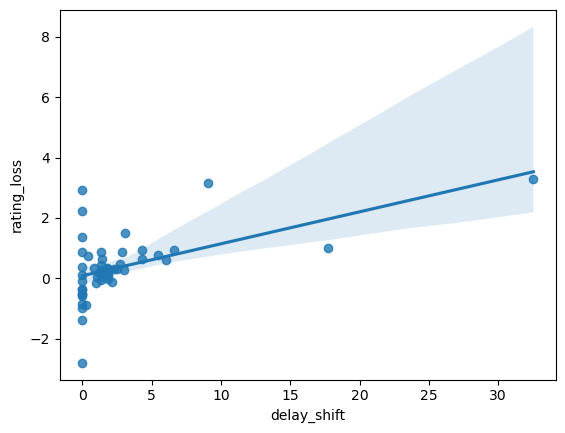

In [60]:
#plt.scatter(df_bf_clean['delay_shift'], df_bf_clean['rating_loss'])
sns.regplot(y='rating_loss', x='delay_shift', data=df_bf_clean)

In [61]:
# BLACK FRIDAY: INCREASE IN SALES VOLUME & DELAY SHIFT

y = df_bf_clean['delay_shift']
x = sm.add_constant(df_bf_clean[['bf_share']])

model = sm.OLS(y, x).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            delay_shift   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.016
Method:                 Least Squares   F-statistic:                    0.4620
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.500
Time:                        17:49:06   Log-Likelihood:                -155.85
No. Observations:                  51   AIC:                             315.7
Df Residuals:                      49   BIC:                             319.6
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0697      1.092      2.810      0.0